# Kentucky Flash Flooding Events, Frequency, & Severity Data Analysis

## EDA: Flash Flooding Events in KY 2015 - 2025 Dataset

In [188]:
# Import libraries and dependencies
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.transforms as mtransforms
import seaborn as sns
import pandas as pd
import numpy as np
import sqlite3

In [189]:
# Read dataset into dataframe
df = pd.read_csv('../data/raw/flash_floods_ky_2015_2025.csv')

In [190]:
# Read first rows of dataset
df.head()

,event_id,cz_name_str,begin_location,begin_date,begin_time,event_type,magnitude,tor_f_scale,deaths_direct,injuries_direct,...,end_date,end_time,begin_lat,begin_lon,end_lat,end_lon,event_narrative,episode_narrative,absolute_rownumber,source_file
0,564702,JEFFERSON CO.,SMYRNA,04/03/2015,348,Flash Flood,,,0,0,...,04/03/2015,348,38.1500,-85.6600,38.1536,-85.6547,Law enforcement reported several water rescues...,A stalled frontal boundary across the area bro...,1,storm_data_search_results_2015.csv
1,564703,JEFFERSON CO.,NEWBURG,04/03/2015,354,Flash Flood,,,0,0,...,04/03/2015,354,38.1600,-85.7000,38.1633,-85.6969,Law enforcement reported evacuations at 6111 G...,A stalled frontal boundary across the area bro...,2,storm_data_search_results_2015.csv
2,564704,ANDERSON CO.,LAWRENCEBURG,04/03/2015,400,Flash Flood,,,0,0,...,04/03/2015,400,38.0229,-84.8866,38.0243,-84.8836,Emergency Management reported several roads cl...,A stalled frontal boundary across the area bro...,3,storm_data_search_results_2015.csv
3,564706,SPENCER CO.,ELK CREEK,04/03/2015,400,Flash Flood,,,0,0,...,04/03/2015,400,38.0994,-85.3742,38.1038,-85.3727,State officials reported numerous water rescue...,A stalled frontal boundary across the area bro...,4,storm_data_search_results_2015.csv
4,564705,JEFFERSON CO.,LOUISVILLE,04/03/2015,400,Flash Flood,,,0,0,...,04/03/2015,400,38.2300,-85.7800,38.2296,-85.7792,Law enforcement reported a road closure near 1...,A stalled frontal boundary across the area bro...,5,storm_data_search_results_2015.csv


In [191]:
# Read last rows of dataset
df.tail()

,event_id,cz_name_str,begin_location,begin_date,begin_time,event_type,magnitude,tor_f_scale,deaths_direct,injuries_direct,...,end_date,end_time,begin_lat,begin_lon,end_lat,end_lon,event_narrative,episode_narrative,absolute_rownumber,source_file
1752,1297632,SPENCER CO.,WILSONVILLE,10/07/2025,1203,Flash Flood,,,0,0,...,10/07/2025,1303,38.1018,-85.4225,38.0623,-85.4013,There was water and debris over Plum Ridge Road.,As a couple of cold fronts moved through the L...,203,storm_data_search_results_2025.csv
1753,1297629,JEFFERSON CO.,MINOR LANE HGTS,10/07/2025,1400,Flash Flood,,,0,0,...,10/07/2025,1500,38.1448,-85.7398,38.1446,-85.7372,Two men were standing on a rock with their lim...,As a couple of cold fronts moved through the L...,204,storm_data_search_results_2025.csv
1754,1295858,FAYETTE CO.,(LEX)BLU GRS FLD LEX,10/07/2025,1430,Flash Flood,,,0,0,...,10/07/2025,1630,38.0251,-84.5896,37.9979,-84.5823,Bowman Mill Road between Old Harrodsburg Road ...,As a couple of cold fronts moved through the L...,205,storm_data_search_results_2025.csv
1755,1295859,FAYETTE CO.,YARNALLTON,10/07/2025,1433,Flash Flood,,,0,0,...,10/07/2025,1633,38.1192,-84.6021,38.1434,-84.6502,Leestown Road between Dolan Lane and the Scott...,As a couple of cold fronts moved through the L...,206,storm_data_search_results_2025.csv
1756,1295860,FAYETTE CO.,VILEY,10/07/2025,1436,Flash Flood,,,0,0,...,10/07/2025,1636,38.0760,-84.5525,38.0748,-84.5509,Alexandria Drive between the Old Frankfort Pik...,As a couple of cold fronts moved through the L...,207,storm_data_search_results_2025.csv


In [192]:
# Check data type and missing values
df.info()

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 40 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   event_id             1757 non-null   int64  
 1   cz_name_str          1757 non-null   str    
 2   begin_location       1757 non-null   str    
 3   begin_date           1757 non-null   str    
 4   begin_time           1757 non-null   int64  
 5   event_type           1757 non-null   str    
 6   magnitude            1757 non-null   str    
 7   tor_f_scale          1757 non-null   str    
 8   deaths_direct        1757 non-null   int64  
 9   injuries_direct      1757 non-null   int64  
 10  damage_property_num  1757 non-null   int64  
 11  damage_crops_num     1757 non-null   int64  
 12  state_abbr           1757 non-null   str    
 13  cz_timezone          1757 non-null   str    
 14  magnitude_type       1757 non-null   str    
 15  episode_id           1757 non-null   int64  
 16 

The event_narrative column has 1749 non-null values. 

In [193]:
# See the dimensions of the dataset
df.shape

(1757, 40)

In [194]:
# Find categorical variables using .select_dtypes()
df.select_dtypes(include='object').columns

C:\Users\msash\AppData\Local\Temp\ipykernel_5984\3561809445.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


Index(['cz_name_str', 'begin_location', 'begin_date', 'event_type',
       'magnitude', 'tor_f_scale', 'state_abbr', 'cz_timezone',
       'magnitude_type', 'cz_type', 'wfo', 'source', 'flood_cause',
       'tor_length', 'tor_width', 'begin_azimuth', 'end_azimuth',
       'end_location', 'end_date', 'event_narrative', 'episode_narrative',
       'source_file'],
      dtype='str')

In [195]:
# Explore value counts for various categorial variables
df.value_counts(subset=['flood_cause']),
df.value_counts(subset=['cz_name_str'])

print(df['flood_cause'].value_counts())
print(df['cz_name_str'].value_counts())

flood_cause
Heavy Rain                      1756
Heavy Rain / Tropical System       1
Name: count, dtype: int64
cz_name_str
JEFFERSON CO.     92
PIKE CO.          44
SIMPSON CO.       39
FLOYD CO.         36
BELL CO.          36
                  ..
WAYNE CO.          3
WOODFORD CO.       3
LIVINGSTON CO.     2
ROBERTSON CO.      2
LYON CO.           2
Name: count, Length: 120, dtype: int64


There is an outlier in the flood_cause column (Heavy Rain / Tropical System). 

In [196]:
# Find row that has the Heavy Rain / Tropical System flood cause
heavy_rain_row = df.loc[df['flood_cause'] == 'Heavy Rain / Tropical System'].iloc[0]
print(heavy_rain_row)

event_id                                                          718430
cz_name_str                                                     TODD CO.
begin_location                                                   GUTHRIE
begin_date                                                    09/01/2017
begin_time                                                           347
event_type                                                   Flash Flood
magnitude                                                               
tor_f_scale                                                             
deaths_direct                                                          0
injuries_direct                                                        0
damage_property_num                                               350000
damage_crops_num                                                       0
state_abbr                                                            KY
cz_timezone                                        

In [197]:
# Sort values using .sort_values()
df.sort_values(by='begin_date', ascending=True)

,event_id,cz_name_str,begin_location,begin_date,begin_time,event_type,magnitude,tor_f_scale,deaths_direct,injuries_direct,...,end_date,end_time,begin_lat,begin_lon,end_lat,end_lon,event_narrative,episode_narrative,absolute_rownumber,source_file
1197,1004921,GREEN CO.,HASKINGSVILLE,01/01/2022,418,Flash Flood,,,0,0,...,01/01/2022,618,37.1899,-85.4155,37.1946,-85.4099,Green County Dispatch reported ongoing water r...,"During New Year's Eve into New Year's Day, act...",1,storm_data_search_results_2022.csv
1198,1004925,BARREN CO.,RAILTON,01/01/2022,500,Flash Flood,,,0,0,...,01/01/2022,700,37.0000,-86.1200,37.0000,-86.1138,Minor flooding at Howser Road and Merry Oaks-R...,"During New Year's Eve into New Year's Day, act...",2,storm_data_search_results_2022.csv
1199,1004927,BARREN CO.,GRIDERVILLE,01/01/2022,500,Flash Flood,,,0,0,...,01/01/2022,700,37.1100,-85.8500,37.1097,-85.8465,Flash flooding occurred along KY SR 70 (Hisevi...,"During New Year's Eve into New Year's Day, act...",3,storm_data_search_results_2022.csv
1200,1004928,GREEN CO.,GRESHAM,01/01/2022,510,Flash Flood,,,0,0,...,01/01/2022,710,37.1799,-85.4371,37.1862,-85.4326,Flash flooding with rapidly moving water flowi...,"During New Year's Eve into New Year's Day, act...",4,storm_data_search_results_2022.csv
1201,1004923,TAYLOR CO.,ROMINE,01/01/2022,520,Flash Flood,,,0,0,...,01/01/2022,720,37.2100,-85.3400,37.2100,-85.3375,Taylor County dispatch reported two vehicles d...,"During New Year's Eve into New Year's Day, act...",5,storm_data_search_results_2022.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,612489,BELL CO.,BEVERLY,12/25/2015,1211,Flash Flood,,,0,0,...,12/25/2015,1400,36.9300,-83.5300,36.9340,-83.5308,Flowing water almost reached the bottom of a c...,Heavy rain and flooding affected portions of e...,233,storm_data_search_results_2015.csv
233,612490,KNOX CO.,FLAT LICK,12/25/2015,1318,Flash Flood,,,0,0,...,12/25/2015,1430,36.8382,-83.7518,36.8363,-83.7505,Lick Branch Road was impassable due to flash f...,Heavy rain and flooding affected portions of e...,234,storm_data_search_results_2015.csv
234,609541,GRAVES CO.,SYMSONIA,12/28/2015,1208,Flash Flood,,,0,0,...,12/28/2015,1500,36.9200,-88.5200,36.9313,-88.5103,Highway 131 was flooded and closed. The floodi...,A cold front lifted north and stalled over the...,235,storm_data_search_results_2015.csv
235,609543,MCCRACKEN CO.,KREBS,12/28/2015,1246,Flash Flood,,,0,0,...,12/28/2015,1500,37.0093,-88.6284,37.0172,-88.7128,Flooding of Champion Creek sent water flowing ...,A cold front lifted north and stalled over the...,236,storm_data_search_results_2015.csv


In [198]:
# Rename columns using .rename()
df.rename(columns={'cz_name_str': 'county_name'}, inplace=True)

print(df.columns.tolist())

['event_id', 'county_name', 'begin_location', 'begin_date', 'begin_time', 'event_type', 'magnitude', 'tor_f_scale', 'deaths_direct', 'injuries_direct', 'damage_property_num', 'damage_crops_num', 'state_abbr', 'cz_timezone', 'magnitude_type', 'episode_id', 'cz_type', 'cz_fips', 'wfo', 'injuries_indirect', 'deaths_indirect', 'source', 'flood_cause', 'tor_length', 'tor_width', 'begin_range', 'begin_azimuth', 'end_range', 'end_azimuth', 'end_location', 'end_date', 'end_time', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'event_narrative', 'episode_narrative', 'absolute_rownumber', 'source_file']


I should drop the magnitude, magnitude_type, tor_f_scale, tor_length, and tor_width columns since there aren't any values within those columns. Plus, these columns aren't relevant to the analysis that I'm conducting at this time.  

In [199]:
# Drop columns using .drop()
df.drop(
    columns=[
        'magnitude',
        'magnitude_type',
        'tor_f_scale',
        'tor_length',
        'tor_width',
        'source_file',
        'absolute_rownumber'
    ],
    inplace=True
)

print(df.columns.tolist())

['event_id', 'county_name', 'begin_location', 'begin_date', 'begin_time', 'event_type', 'deaths_direct', 'injuries_direct', 'damage_property_num', 'damage_crops_num', 'state_abbr', 'cz_timezone', 'episode_id', 'cz_type', 'cz_fips', 'wfo', 'injuries_indirect', 'deaths_indirect', 'source', 'flood_cause', 'begin_range', 'begin_azimuth', 'end_range', 'end_azimuth', 'end_location', 'end_date', 'end_time', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'event_narrative', 'episode_narrative']


Columns such as begin_date and end_date may need their data types changed since I plan to conduct numerical analysis with them. 

In [200]:
# Fix data types using .astype()
df = df.astype({'begin_date': 'datetime64[ns]'})
df = df.astype({'end_date': 'datetime64[ns]'})
df = df.astype({'event_id': 'string'})
df = df.astype({'begin_time': 'string'})
df = df.astype({'end_time': 'string'})
df = df.astype({'episode_id': 'string'})
df = df.astype({'cz_fips': 'string'})
df = df.astype({'event_narrative': 'string'})
df = df.astype({'episode_narrative': 'string'})

print(df.dtypes)

event_id                       string
county_name                       str
begin_location                    str
begin_date             datetime64[ns]
begin_time                     string
event_type                        str
deaths_direct                   int64
injuries_direct                 int64
damage_property_num             int64
damage_crops_num                int64
state_abbr                        str
cz_timezone                       str
episode_id                     string
cz_type                           str
cz_fips                        string
wfo                               str
injuries_indirect               int64
deaths_indirect                 int64
source                            str
flood_cause                       str
begin_range                   float64
begin_azimuth                     str
end_range                     float64
end_azimuth                       str
end_location                      str
end_date               datetime64[ns]
end_time    

I decided to change the data type of columns such as EVENT_ID, EVENT_NARRATIVE, and EPISODE_NARRATIVE to string since I will not be using these columns for numerical analysis at this time. 

In [201]:
# Identify missing values using .isnull() and/or .notnull()
df.isnull().sum()

event_id               0
county_name            0
begin_location         0
begin_date             0
begin_time             0
event_type             0
deaths_direct          0
injuries_direct        0
damage_property_num    0
damage_crops_num       0
state_abbr             0
cz_timezone            0
episode_id             0
cz_type                0
cz_fips                0
wfo                    0
injuries_indirect      0
deaths_indirect        0
source                 0
flood_cause            0
begin_range            0
begin_azimuth          0
end_range              0
end_azimuth            0
end_location           0
end_date               0
end_time               0
begin_lat              0
begin_lon              0
end_lat                0
end_lon                0
event_narrative        8
episode_narrative      0
dtype: int64

In [202]:
# View rows with missing values
df[df.isnull().any(axis=1)] 

print(df[df['event_narrative'].isnull()])

     event_id    county_name      begin_location begin_date begin_time  \
1448  1102154     GRAVES CO.               LOWES 2023-07-19         56   
1449  1102165   CALLOWAY CO.          LYNN GROVE 2023-07-19        356   
1450  1102183     FULTON CO.          ANNA LYNNE 2023-07-19        430   
1451  1102181   CARLISLE CO.           ARLINGTON 2023-07-19        445   
1452  1102170    HICKMAN CO.              BEULAH 2023-07-19        538   
1453  1102172  MCCRACKEN CO.                OAKS 2023-07-19        625   
1454  1102178    BALLARD CO.               KEVIL 2023-07-19        629   
1455  1102185   MARSHALL CO.  GILBERTSVILLE ARPT 2023-07-19        830   

       event_type  deaths_direct  injuries_direct  damage_property_num  \
1448  Flash Flood              0                0              2000000   
1449  Flash Flood              0                0               500000   
1450  Flash Flood              0                0               100000   
1451  Flash Flood              0     

event_narrative values are missing from 07-19-2023. I'm not going to be using event_narrative data at this time, so I will just fill those missing values in with "Unknown." 

In [203]:
# Replace missing values in EVENT_NARRATIVE with "Unknown"
df["event_narrative"] = df["event_narrative"].fillna("Unknown")

print(df["event_narrative"].isna().sum())

0


In [204]:
# Check for duplicate rows using .duplicated()
df.duplicated().sum()

np.int64(0)

In [205]:
# Create YEAR column
df["year"] = df["begin_date"].dt.year

df = df.astype({'year': 'int64'})

print(df["year"].value_counts())

year
2015    237
2021    217
2025    207
2018    169
2020    165
2022    163
2016    156
2019    133
2023    121
2017    120
2024     69
Name: count, dtype: int64


In [206]:
# Check data to ensure that YEAR column was added correctly. 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 34 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   event_id             1757 non-null   string        
 1   county_name          1757 non-null   str           
 2   begin_location       1757 non-null   str           
 3   begin_date           1757 non-null   datetime64[ns]
 4   begin_time           1757 non-null   string        
 5   event_type           1757 non-null   str           
 6   deaths_direct        1757 non-null   int64         
 7   injuries_direct      1757 non-null   int64         
 8   damage_property_num  1757 non-null   int64         
 9   damage_crops_num     1757 non-null   int64         
 10  state_abbr           1757 non-null   str           
 11  cz_timezone          1757 non-null   str           
 12  episode_id           1757 non-null   string        
 13  cz_type              1757 non-null   str    

In [207]:
# Save cleaned dataset to new csv file
df.to_csv('../data/processed/flash_floods_ky_2015_2025_cleaned.csv', index=False)

In [208]:
# Use .groupby() to explore number of flash flooding events by county.
county_counts = (
    df.groupby("county_name")
    .size()
    .reset_index(name="total_events")
    .sort_values("total_events", ascending=False)
)

# View top 10 counties with most flash flooding events
print(county_counts.head(10))

       county_name  total_events
55   JEFFERSON CO.            92
97        PIKE CO.            44
106    SIMPSON CO.            39
6         BELL CO.            36
35       FLOYD CO.            36
78   MCCRACKEN CO.            30
17    CALLOWAY CO.            27
12   BREATHITT CO.            26
104      SCOTT CO.            25
44     GREENUP CO.            24


In [209]:
# Use .groupby() to explore total property damage by county
property_damage = (
    df.groupby("county_name")["damage_property_num"]
    .sum()
    .reset_index()
    .sort_values("damage_property_num", ascending=False)
)

# View top 10 counties with most property damage from flash flooding events
print(property_damage.head(10))

      county_name  damage_property_num
17   CALLOWAY CO.              3965000
57    JOHNSON CO.              3514000
21     CARTER CO.              2771750
82    MENIFEE CO.              2634500
75   MARSHALL CO.              2625000
37     FULTON CO.              2195000
41     GRAVES CO.              2120000
90   NICHOLAS CO.              2000000
63   LAWRENCE CO.              1628750
55  JEFFERSON CO.              1616000


In [210]:
# Use .groupby() to explore total deaths and injuries by county
human_impact = (
    df.groupby("county_name")[["deaths_direct", "injuries_direct"]]
    .sum()
    .reset_index()
    .sort_values("deaths_direct", ascending=False)
)

# View top 10 counties with the most direct deaths and injuries from flash flooding events
print(human_impact.head(10))

      county_name  deaths_direct  injuries_direct
59      KNOTT CO.             16                0
12  BREATHITT CO.             10                0
96      PERRY CO.              7                0
57    JOHNSON CO.              4               15
66    LETCHER CO.              3                0
25       CLAY CO.              3                0
49       HART CO.              2                0
90   NICHOLAS CO.              2                0
36   FRANKLIN CO.              2                0
16   CALDWELL CO.              1                0


In [211]:
# Use .groupby() to explore how many flash flooding events were reported from each source from 2015 - 2025
source_counts = (
    df.groupby("source")
      .size()
      .reset_index(name="total_events")
      .sort_values("total_events", ascending=False)
)

print(source_counts)

                    source  total_events
0          911 Call Center           378
8        Emergency Manager           365
16                  Public           228
10         Law Enforcement           192
2          Broadcast Media           143
20         Trained Spotter           122
6   Department of Highways            90
18          State Official            90
12            NWS Employee            40
9   Fire Department/Rescue            32
17            Social Media            19
1            Amateur Radio            17
5          County Official            12
3            COOP Observer             7
14               Newspaper             6
22         Utility Company             4
19            Storm Chaser             3
11                 Mesonet             3
15    Other Federal Agency             2
13        NWS Storm Survey             1
7          Drought Monitor             1
4                 CoCoRaHS             1
21                 Unknown             1


911 Call Centers have reported the most flash flooding events from 2015 - 2025.

In [212]:
# Use .groupby() to explore the top 5 dates that had the most flash flooding events
date_counts = (
    df.groupby("begin_date")
      .size()
      .reset_index(name="total_events")
      .sort_values("total_events", ascending=False)
)

print(date_counts.head(5))

    begin_date  total_events
324 2025-02-15            61
20  2015-07-14            54
0   2015-04-03            51
271 2023-01-03            42
133 2019-02-23            41


In [213]:
# Use .groupby() to explore the counties and cities that experienced flash flooding events on the top 5 dates. Show the dates and the total number of events for each county on those dates.
top_dates = date_counts.head(5)["begin_date"]
county_city_date_counts = (
    df[df["begin_date"].isin(top_dates)]
    .groupby(["begin_date", "county_name", "begin_location", "begin_lat", "begin_lon"])
    .size()
    .reset_index(name="total_events")
    .sort_values(["begin_date", "total_events"], ascending=[True, False])
)

print(county_city_date_counts)

    begin_date    county_name begin_location  begin_lat  begin_lon  \
14  2015-04-03      FLOYD CO.        BONANZA    37.6900   -82.8600   
0   2015-04-03   ANDERSON CO.   LAWRENCEBURG    38.0229   -84.8866   
1   2015-04-03       BATH CO.    OWINGSVILLE    38.1400   -83.7600   
2   2015-04-03       BATH CO.      SALT LICK    38.1100   -83.6300   
3   2015-04-03  BREATHITT CO.         LAWSON    37.6000   -83.4600   
..         ...            ...            ...        ...        ...   
242 2025-02-15     WARREN CO.         COHRON    37.0300   -86.6000   
243 2025-02-15    WEBSTER CO.           CLAY    37.4900   -87.8500   
244 2025-02-15    WEBSTER CO.        ELMWOOD    37.5200   -87.5000   
245 2025-02-15    WEBSTER CO.        ELMWOOD    37.5213   -87.5311   
246 2025-02-15    WEBSTER CO.          LUZON    37.5281   -87.7504   

     total_events  
14              2  
0               1  
1               1  
2               1  
3               1  
..            ...  
242             1  

In [214]:
# Sort values to determine which flash flooding events were the most expensive
highest_damage = df.sort_values("damage_property_num", ascending=False)
print(highest_damage[
    ["begin_date", "county_name", "damage_property_num"]
].head(10))

     begin_date    county_name  damage_property_num
144  2015-07-13    JOHNSON CO.              3500000
989  2021-02-28   CALLOWAY CO.              2900000
472  2017-06-23     CARTER CO.              2300000
1466 2023-08-04     FULTON CO.              2000000
1139 2021-07-30    MENIFEE CO.              2000000
1448 2023-07-19     GRAVES CO.              2000000
316  2016-07-07   MARSHALL CO.              2000000
117  2015-07-07  MCCRACKEN CO.              1200000
33   2015-04-03    BULLITT CO.              1000000
1133 2021-07-30   NICHOLAS CO.              1000000


In [215]:
# Sort Values to determine which flash flooding events had the most injuries
most_injuries = df.sort_values("injuries_direct", ascending=False)
print(most_injuries[
    ["begin_date", "county_name", "injuries_direct"]
].head(10))

     begin_date     county_name  injuries_direct
144  2015-07-13     JOHNSON CO.               15
903  2020-06-29  WASHINGTON CO.                1
0    2015-04-03   JEFFERSON CO.                0
1180 2021-08-30      MCLEAN CO.                0
1178 2021-08-30      SHELBY CO.                0
1177 2021-08-30        PIKE CO.                0
1176 2021-08-30        PIKE CO.                0
1175 2021-08-30        PIKE CO.                0
1174 2021-08-30        PIKE CO.                0
1173 2021-08-30        PIKE CO.                0


In [216]:
# Create a summary table for the following question: What has been the total statewide impact of flash flooding in Kentucky from 2015-2025?
summary = pd.DataFrame({
    "total events": [len(df)],
    "total property damage": [df["damage_property_num"].sum()],
    "total deaths": [df["deaths_direct"].sum()],
    "total injuries": [df["injuries_direct"].sum()]
})

print(summary)

   total events  total property damage  total deaths  total injuries
0          1757               42634460            64              16


In [217]:
# Create a summary table for the following question: How has reporting sources changed over time?
source_year = pd.crosstab(df["year"], df["source"])

print(source_year)

source  911 Call Center  Amateur Radio  Broadcast Media  COOP Observer  \
year                                                                     
2015                 12              1               22              0   
2016                 12              1               13              1   
2017                 15              1                8              3   
2018                 26             13               36              1   
2019                 39              0               16              0   
2020                 38              0               20              0   
2021                 72              0               16              1   
2022                 45              0                5              1   
2023                 34              0                3              0   
2024                 17              1                1              0   
2025                 68              0                3              0   

source  CoCoRaHS  County Official  De

This information can be used to create a heatmap of how reporting has changed for each source over time. 

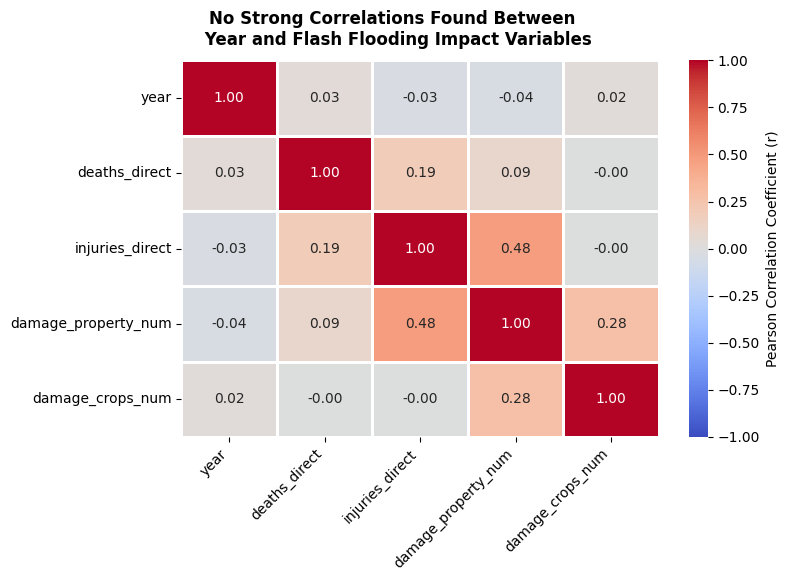

In [218]:
# Create a heatmap that shows correlations between numerical variables
events_df = pd.read_csv('../data/processed/flash_floods_ky_2015_2025_cleaned.csv')

cols = [
    "year",
    "deaths_direct",
    "injuries_direct",
    "damage_property_num",
    "damage_crops_num"
]
corr_matrix = events_df[cols].corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",  
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"},
)

plt.suptitle(
    "No Strong Correlations Found Between \n Year and Flash Flooding Impact Variables",
    fontsize=12,
    fontweight="bold",
    y=0.96,
)

plt.xticks(
    rotation=45, 
    ha="right"
)

plt.tight_layout()
plt.show()

1. What question or idea does this chart help answer?
This chart shows whether there are linear relationships between year and key flash flood impact variables, as well as relationships among the impact variables themselves. It helps identify whether any variables tend to increase, decrease, or move together over time.
2. Why is this chart type appropriate?
A correlation heatmap is appropriate because it allows multiple relationships to be visualized in a single view. It summarizes how several numeric variables relate to one another without needing many separate plots.
3. What design choices did you make (color, labels, order, scale)?
I used a diverging “coolwarm” color palette with a fixed range from -1 to 1 to clearly show direction and strength of correlations. I rotated labels for readability. I kept axis names consistent to make comparisons easier.
4. How did you ensure accuracy and avoid misleading design?
I ensured that the heatmap used Pearson correlation values directly from the dataset without transformation, ensuring mathematical accuracy. The full -1 to 1 scale and consistent labeling aids in preventing exaggeration or misinterpretation of relationships.

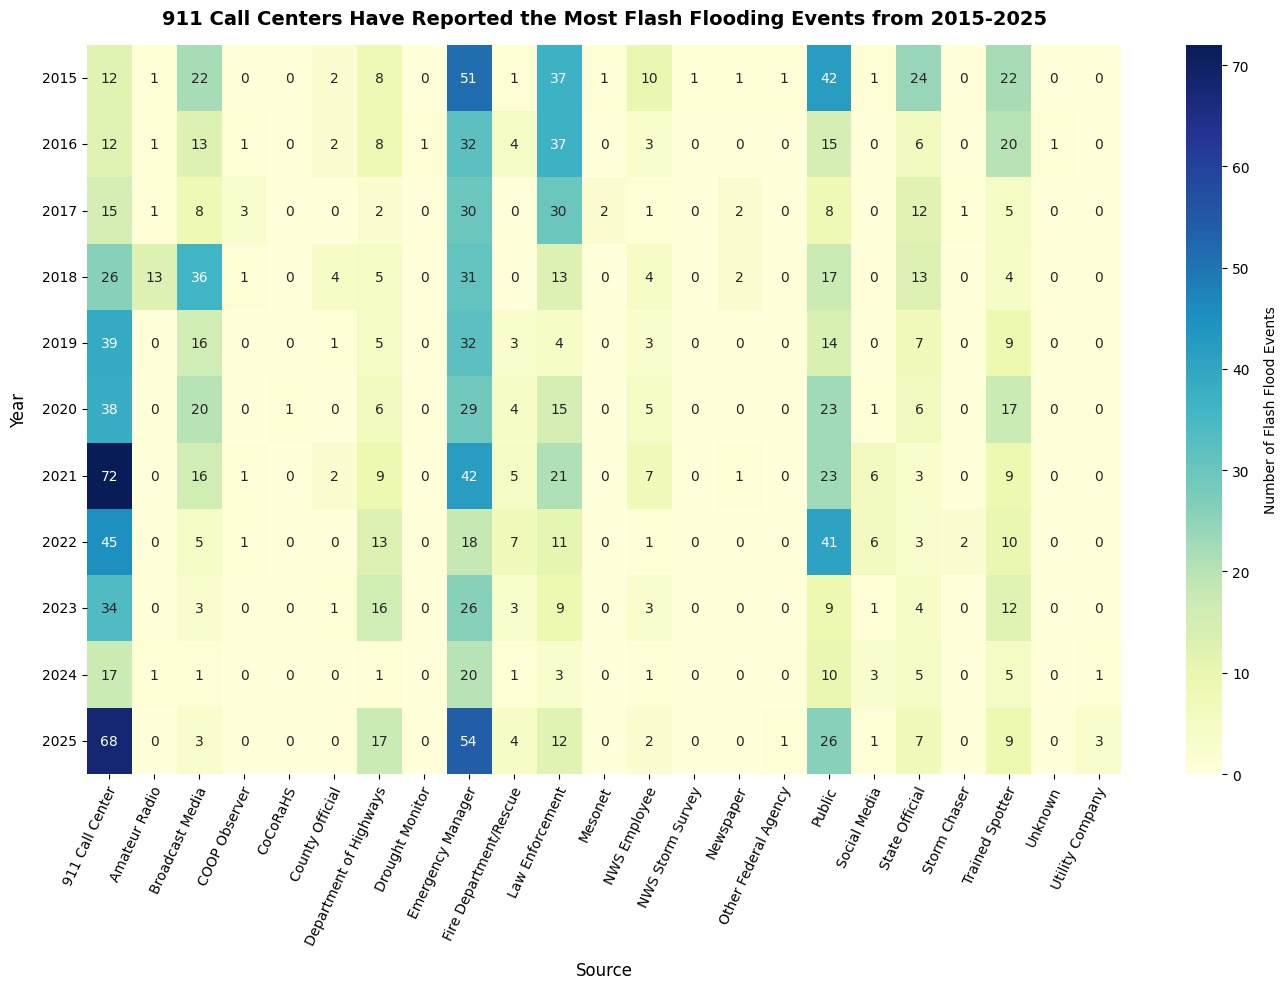

In [219]:
# Create a heatmap that shows correlations between years and sources
events_df = pd.read_csv('../data/processed/flash_floods_ky_2015_2025_cleaned.csv')

source_year = pd.crosstab(events_df["year"], events_df["source"])

plt.figure(figsize=(14, 10))

ax = sns.heatmap(
    source_year, 
    annot=True, 
    cmap="YlGnBu", 
    fmt="d"
)

cbar = ax.collections[0].colorbar
cbar.set_label(
    "Number of Flash Flood Events", 
    labelpad=10)

plt.title(
    "911 Call Centers Have Reported the Most Flash Flooding Events from 2015-2025", 
    fontsize=14, 
    fontweight="bold", 
    pad=15,
    ha="center"
)

plt.xlabel(
    "Source", 
    fontsize=12, 
    labelpad=10
)

plt.ylabel(
    "Year", 
    fontsize=12, 
    labelpad=10
)

ax.set_xticklabels(
    source_year.columns, 
    rotation=65, 
    ha="right"
)

ax.set_yticklabels(
    source_year.index, 
    rotation=0, 
    ha="right"
)

offset = mtransforms.ScaledTranslation(8 / 78, 0, plt.gcf().dpi_scale_trans)

for label in ax.get_xticklabels():
    label.set_transform(label.get_transform() + offset)

plt.tight_layout()
plt.show()

1. What question or idea does this chart help answer?
This chart shows how the number of flash flood events varies by reporting source across each year. It helps identify which sources, such as 911 call centers, report the most events over time.
2. Why is this chart type appropriate?
A heatmap is appropriate because it allows comparison of counts across two categorical variables (year and source) in a compact visual format. It makes patterns in reporting volume easy to spot across both dimensions.
3. What design choices did you make (color, labels, order, scale)?
I chose to use the “YlGnBu” color palette to represent increasing event counts, with annotations added to show exact values in each cell. I made adjustments to axis labels, rotations, and spacing adjustments to improve readability of densely packed categories.
4. How did you ensure accuracy and avoid misleading design?
I ensured that the chart used raw counts from a crosstab without normalization so that values directly reflected event totals. I used Consistent labeling, clear axis definitions, and annotated values to help prevent misinterpretation of relative differences.

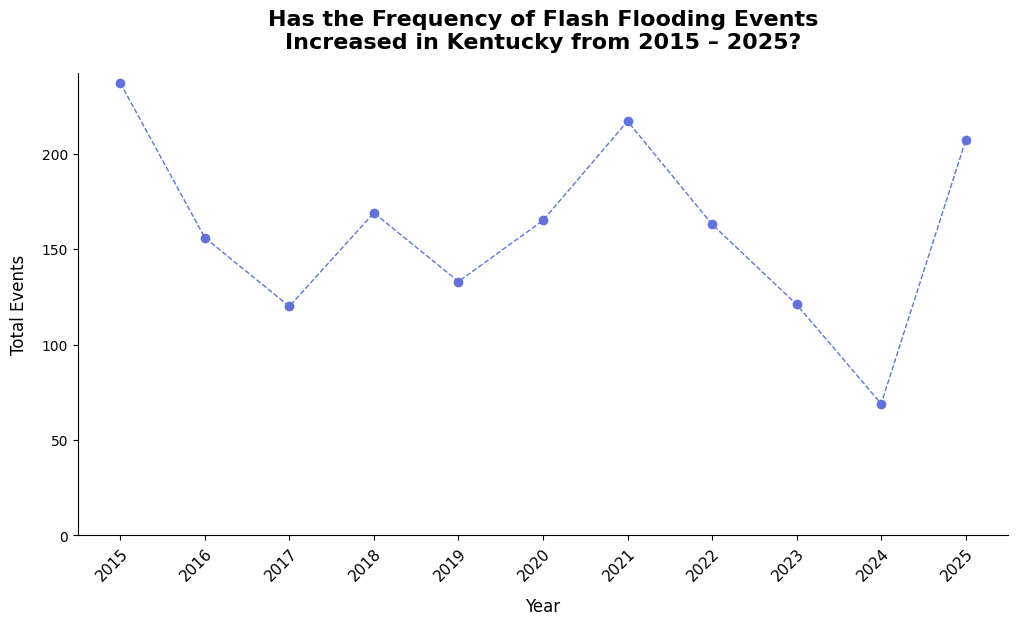

In [220]:
# Create a line graph that shows total flash flooding events per year from 2015-2025
events_df = pd.read_csv('../data/processed/flash_floods_ky_2015_2025_cleaned.csv')

events_per_year = events_df["year"].value_counts().sort_index()

plt.figure(figsize=(12, 6))

ax = plt.gca()
ax.plot(
    events_per_year.index, events_per_year.values, 
    marker="o", linestyle="--", 
    linewidth=1, 
    color="#6272dc"
)

ax.set_title(
    "Has the Frequency of Flash Flooding Events\nIncreased in Kentucky from 2015 – 2025?", 
    fontsize=16, 
    fontweight="bold", 
    pad=18
)

ax.set_xlabel(
    "Year", 
    fontsize=12, 
    labelpad=10
)

ax.set_ylabel(
    "Total Events", 
    fontsize=12, 
    labelpad=10
)

ax.set_xticks(events_per_year.index)
ax.set_xticklabels(
    events_per_year.index, 
    rotation=45, 
    ha="right", 
    rotation_mode="anchor", 
    fontsize=11
)

ax.set_ylim(0, events_per_year.max() + 5)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.show()

1. What question or idea does this chart help answer?
This chart examines whether the frequency of flash flooding events in Kentucky has increased over time from 2015 to 2025. It highlights year-to-year trends in total event counts to show overall change patterns.
2. Why is this chart type appropriate?
A line chart is appropriate because it effectively shows trends over time and makes it easy to see increases or decreases across consecutive years. It is well-suited for time-series data like annual event counts.
3. What design choices did you make (color, labels, order, scale)?
I decided to use single blue line with markers and a dashed style to clearly show both trend and individual data points, while axis labels and rotated year ticks were changed to improve readability. I adjusted the y-axis to start at zero to avoid exaggerating changes.
4. How did you ensure accuracy and avoid misleading design?
I used sorted yearly counts to maintain correct chronological order and included a consistent y-axis scale starting at zero. I also removed unnecessary spines and used clear labeling to prevent visual distortion or misinterpretation of trends.

It appears that there hasn't been a significant increase in flash flooding frequency in Kentucky from 2015 - 2025.

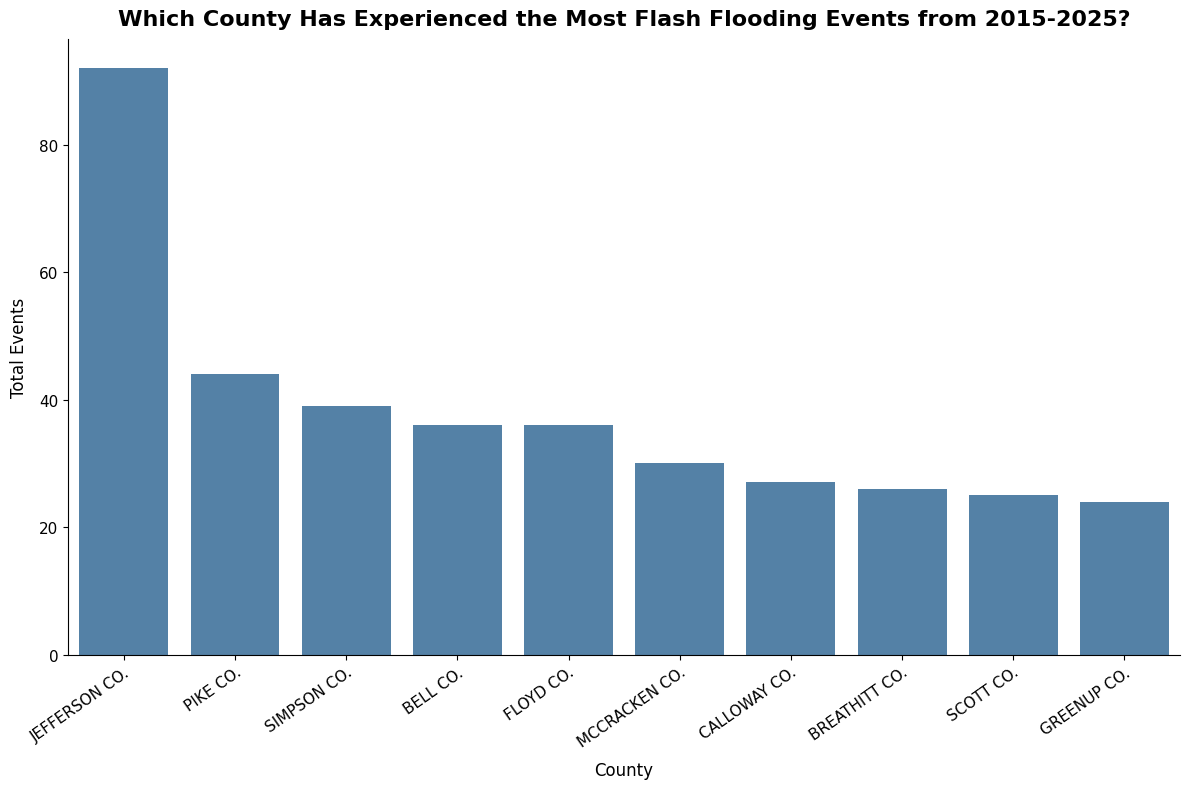

In [221]:
# Create a bar chart that shows the top 10 counties that have experienced the most flash flooding events from 2015 - 2025
events_df = pd.read_csv('../data/processed/flash_floods_ky_2015_2025_cleaned.csv')

county_counts = (
    events_df.groupby("county_name")
    .size()
    .reset_index(name="total_events")
    .sort_values("total_events", ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 8))

ax = sns.barplot(
    data=county_counts, 
    x="county_name", 
    y="total_events", 
    color="steelblue"
)

plt.title(
    "Which County Has Experienced the Most Flash Flooding Events from 2015-2025?", 
    fontsize=16, 
    fontweight="bold", 
    pad=10
)

plt.xlabel(
    "County", 
    fontsize=12, 
    labelpad=8
)

plt.ylabel(
    "Total Events", 
    fontsize=12, 
    labelpad=8
)

plt.xticks(
    rotation=35, 
    ha="right", 
    rotation_mode="anchor", 
    fontsize=11
)

plt.yticks(fontsize=11)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

1. What question or idea does this chart help answer?
This chart identifies which top 10 counties in Kentucky experienced the highest number of flash flooding events from 2015 to 2025. It helps compare event frequency across these top 10 counties.
2. Why is this chart type appropriate?
A bar chart is appropriate because it clearly compares discrete categories (counties) based on their total event counts. It makes it easy to rank and visually distinguish differences between counties.
3. What design choices did you make (color, labels, order, scale)?
I decided to use a single “steelblue” color for the bars to keep focus on comparison rather than aesthetics. I sorted counties in descending order to highlight the highest-impact locations. I adjusted axis labels, rotation, and font sizing to improve readability.
4. How did you ensure accuracy and avoid misleading design?
I grouped and sorted directly from raw event counts without transformation, ensuring accurate totals for each county. I limited the plot to the top 10 counties in order to prevent clutter while still accurately representing the highest values.

## EDA: Flash Floods KY Weather Conditions Dataset

In [222]:
# Read dataset into dataframe
df = pd.read_csv('../data/raw/flash_floods_ky_weather_conditions.csv')

In [223]:
# Read first rows of dataset
df.head()

,event_id,county_name,begin_location,begin_date,begin_time,event_type,deaths_direct,injuries_direct,damage_property_num,damage_crops_num,...,avgtemp_f,maxwind_mph,totalprecip_in,avgvis_miles,avghumidity,uv,daily_will_it_rain,daily_chance_of_rain,condition_text,condition_code
0,564702,JEFFERSON CO.,SMYRNA,2015-04-03,348,Flash Flood,0,0,0,0,...,58.9,13.9,2.19,4.0,95,2.7,1,100,Moderate or heavy rain shower,1243
1,564703,JEFFERSON CO.,NEWBURG,2015-04-03,354,Flash Flood,0,0,20000,0,...,58.9,13.9,2.19,4.0,95,2.7,1,100,Moderate or heavy rain shower,1243
2,564704,ANDERSON CO.,LAWRENCEBURG,2015-04-03,400,Flash Flood,0,0,30000,0,...,59.1,17.7,2.67,4.0,96,1.3,1,100,Moderate or heavy rain shower,1243
3,564706,SPENCER CO.,ELK CREEK,2015-04-03,400,Flash Flood,0,0,30000,0,...,58.7,15.4,2.65,3.0,95,1.9,1,100,Moderate or heavy rain shower,1243
4,564705,JEFFERSON CO.,LOUISVILLE,2015-04-03,400,Flash Flood,0,0,0,0,...,58.2,13.0,2.03,4.0,95,2.7,1,100,Moderate or heavy rain shower,1243


In [224]:
# Read last rows of dataset
df.tail()

,event_id,county_name,begin_location,begin_date,begin_time,event_type,deaths_direct,injuries_direct,damage_property_num,damage_crops_num,...,avgtemp_f,maxwind_mph,totalprecip_in,avgvis_miles,avghumidity,uv,daily_will_it_rain,daily_chance_of_rain,condition_text,condition_code
1752,1297632,SPENCER CO.,WILSONVILLE,2025-10-07,1203,Flash Flood,0,0,0,0,...,66.6,6.9,1.25,3.0,96,2.6,1,100,Moderate or heavy rain shower,1243
1753,1297629,JEFFERSON CO.,MINOR LANE HGTS,2025-10-07,1400,Flash Flood,0,0,0,0,...,68.4,5.8,1.09,4.0,95,2.7,1,100,Heavy rain,1195
1754,1295858,FAYETTE CO.,(LEX)BLU GRS FLD LEX,2025-10-07,1430,Flash Flood,0,0,0,0,...,65.8,3.8,0.70,5.0,82,3.7,1,100,Fog,1135
1755,1295859,FAYETTE CO.,YARNALLTON,2025-10-07,1433,Flash Flood,0,0,0,0,...,66.1,8.9,1.22,3.0,94,3.1,1,100,Heavy rain,1195
1756,1295860,FAYETTE CO.,VILEY,2025-10-07,1436,Flash Flood,0,0,0,0,...,66.1,8.9,1.22,3.0,94,3.1,1,100,Heavy rain,1195


In [225]:
# Check data type and missing values
df.info()

print(df.columns.tolist())

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 46 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_id              1757 non-null   int64  
 1   county_name           1757 non-null   str    
 2   begin_location        1757 non-null   str    
 3   begin_date            1757 non-null   str    
 4   begin_time            1757 non-null   int64  
 5   event_type            1757 non-null   str    
 6   deaths_direct         1757 non-null   int64  
 7   injuries_direct       1757 non-null   int64  
 8   damage_property_num   1757 non-null   int64  
 9   damage_crops_num      1757 non-null   int64  
 10  state_abbr            1757 non-null   str    
 11  cz_timezone           1757 non-null   str    
 12  episode_id            1757 non-null   int64  
 13  cz_type               1757 non-null   str    
 14  cz_fips               1757 non-null   int64  
 15  wfo                   1757 non-n

In [226]:
# See the dimensions of the dataset
df.shape

(1757, 46)

In [227]:
# Find categorical variables using .select_dtypes()
df.select_dtypes(include='object').columns
print(df.columns.tolist())

['event_id', 'county_name', 'begin_location', 'begin_date', 'begin_time', 'event_type', 'deaths_direct', 'injuries_direct', 'damage_property_num', 'damage_crops_num', 'state_abbr', 'cz_timezone', 'episode_id', 'cz_type', 'cz_fips', 'wfo', 'injuries_indirect', 'deaths_indirect', 'source', 'flood_cause', 'begin_range', 'begin_azimuth', 'end_range', 'end_azimuth', 'end_location', 'end_date', 'end_time', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'event_narrative', 'episode_narrative', 'year', 'maxtemp_f', 'mintemp_f', 'avgtemp_f', 'maxwind_mph', 'totalprecip_in', 'avgvis_miles', 'avghumidity', 'uv', 'daily_will_it_rain', 'daily_chance_of_rain', 'condition_text', 'condition_code']


C:\Users\msash\AppData\Local\Temp\ipykernel_5984\2088171777.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include='object').columns


In [228]:
# Drop columns using .drop()
df.drop(columns=[
    'event_type',
    'state_abbr', 
    'cz_timezone', 
    'episode_id', 
    'cz_type', 
    'cz_fips', 
    'wfo',
    'source',
    'begin_azimuth',
    'end_azimuth',
    'flood_cause',
    'event_narrative', 
    'episode_narrative'
], inplace=True)

print(df.columns.tolist())

['event_id', 'county_name', 'begin_location', 'begin_date', 'begin_time', 'deaths_direct', 'injuries_direct', 'damage_property_num', 'damage_crops_num', 'injuries_indirect', 'deaths_indirect', 'begin_range', 'end_range', 'end_location', 'end_date', 'end_time', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'year', 'maxtemp_f', 'mintemp_f', 'avgtemp_f', 'maxwind_mph', 'totalprecip_in', 'avgvis_miles', 'avghumidity', 'uv', 'daily_will_it_rain', 'daily_chance_of_rain', 'condition_text', 'condition_code']


In [229]:
# Save Cleaned Dataset
df.to_csv('../data/processed/flash_floods_ky_weather_conditions_data.csv', index=False)

In [230]:
# Create Flash Floods KY Events Info CSV file
df = pd.read_csv('../data/processed/flash_floods_ky_weather_conditions_data.csv')

df.drop(columns=[
    "maxtemp_f", 
    "mintemp_f", 
    "avgtemp_f", 
    "maxwind_mph", 
    "totalprecip_in", 
    "avgvis_miles", 
    "avghumidity", 
    "condition_text", 
    "condition_code", 
    "uv", 
    "daily_will_it_rain", 
    "daily_chance_of_rain"
], inplace=True)

df.to_csv('../data/processed/flash_floods_ky_event_info.csv', index=False)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 21 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   event_id             1757 non-null   int64  
 1   county_name          1757 non-null   str    
 2   begin_location       1757 non-null   str    
 3   begin_date           1757 non-null   str    
 4   begin_time           1757 non-null   int64  
 5   deaths_direct        1757 non-null   int64  
 6   injuries_direct      1757 non-null   int64  
 7   damage_property_num  1757 non-null   int64  
 8   damage_crops_num     1757 non-null   int64  
 9   injuries_indirect    1757 non-null   int64  
 10  deaths_indirect      1757 non-null   int64  
 11  begin_range          1757 non-null   float64
 12  end_range            1757 non-null   float64
 13  end_location         1757 non-null   str    
 14  end_date             1757 non-null   str    
 15  end_time             1757 non-null   int64  
 16 

# Flash Floods Ky Event Info Dataset Cleaning

In [231]:
# Read dataset into dataframe
df = pd.read_csv('../data/processed/flash_floods_ky_event_info.csv')

In [232]:
# Convert event_id to string
df['event_id'] = df['event_id'].astype(str)

In [233]:
# Convert date strings to datetime objects
b_date = pd.to_datetime(df['begin_date'], format='mixed')
e_date = pd.to_datetime(df['end_date'], format='mixed')

In [234]:
# Standardize time ints into 4-digit strings
b_time_str = df['begin_time'].astype(str).str.zfill(4)
e_time_str = df['end_time'].astype(str).str.zfill(4)

In [235]:
# Create unified temporary datetime series
start_dt = pd.to_datetime(b_date.dt.strftime('%Y-%m-%d') + ' ' + b_time_str, format='%Y-%m-%d %H%M')
end_dt = pd.to_datetime(e_date.dt.strftime('%Y-%m-%d') + ' ' + e_time_str, format='%Y-%m-%d %H%M')

In [236]:
# Calculate precise durations
df['duration_minutes'] = (end_dt - start_dt).dt.total_seconds() / 60.0
df['duration_hours'] = df['duration_minutes'] / 60.0

In [237]:
# Round durations to 2 decimal places
df['duration_hours'] = df['duration_hours'].round(2)

In [238]:
# Save updated DataFrame to CSV file
df.to_csv('../data/processed/flash_floods_ky_event_info.csv', index=False)

# Flash Floods Ky Impact Dataset Creation & Cleaning

In [239]:
# Read dataset into dataframe
df = pd.read_csv('../data/processed/flash_floods_ky_event_info.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   event_id             1757 non-null   int64  
 1   county_name          1757 non-null   str    
 2   begin_location       1757 non-null   str    
 3   begin_date           1757 non-null   str    
 4   begin_time           1757 non-null   int64  
 5   deaths_direct        1757 non-null   int64  
 6   injuries_direct      1757 non-null   int64  
 7   damage_property_num  1757 non-null   int64  
 8   damage_crops_num     1757 non-null   int64  
 9   injuries_indirect    1757 non-null   int64  
 10  deaths_indirect      1757 non-null   int64  
 11  begin_range          1757 non-null   float64
 12  end_range            1757 non-null   float64
 13  end_location         1757 non-null   str    
 14  end_date             1757 non-null   str    
 15  end_time             1757 non-null   int64  
 16 

In [240]:
# Convert event_id to string
df['event_id'] = df['event_id'].astype(str)

In [241]:
# Drop columns
df.drop(columns=[
    "begin_location", 
    "begin_date", 
    "begin_time",
    "begin_range", 
    "end_range", 
    "end_location", 
    "end_date", 
    "end_time", 
    "begin_lat", 
    "begin_lon", 
    "end_lat", 
    "end_lon", 
    "year", 
    "duration_minutes",
    "duration_hours"
], inplace=True)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   event_id             1757 non-null   str  
 1   county_name          1757 non-null   str  
 2   deaths_direct        1757 non-null   int64
 3   injuries_direct      1757 non-null   int64
 4   damage_property_num  1757 non-null   int64
 5   damage_crops_num     1757 non-null   int64
 6   injuries_indirect    1757 non-null   int64
 7   deaths_indirect      1757 non-null   int64
dtypes: int64(6), str(2)
memory usage: 138.9 KB


In [242]:
# Save CSV file
df.to_csv('../data/processed/flash_floods_ky_impact_data.csv', index=False)

# Flash Floods Ky Moon & Sun Dataset Cleaning

In [243]:
# Read dataset into dataframe
df = pd.read_csv('../data/processed/flash_floods_ky_moon_sun_data.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1757 entries, 0 to 1756
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   event_id               1757 non-null   int64  
 1   sun_altitude_deg       1757 non-null   float64
 2   sun_azimuth_deg        1757 non-null   float64
 3   sunrise_utc            1757 non-null   str    
 4   sunset_utc             1757 non-null   str    
 5   moon_altitude_deg      1757 non-null   float64
 6   moon_azimuth_deg       1757 non-null   float64
 7   moon_phase_name        1757 non-null   str    
 8   moon_illumination_pct  1757 non-null   float64
dtypes: float64(5), int64(1), str(3)
memory usage: 211.0 KB


In [244]:
# Convert event_id to string
df['event_id'] = df['event_id'].astype(str)

In [245]:
# Save CSV file
df.to_csv('../data/processed/flash_floods_ky_moon_sun_data.csv', index=False)

# Build SQL Relational Tables

In [247]:
df_event_info = pd.read_csv("../data/processed/flash_floods_ky_event_info.csv")
df_impact_data = pd.read_csv("../data/processed/flash_floods_ky_impact_data.csv")
df_weather_conditions = pd.read_csv("../data/processed/flash_floods_ky_weather_conditions_data.csv")
df_moon_sun_data = pd.read_csv("../data/processed/flash_floods_ky_moon_sun_data.csv")
df_oni_data = pd.read_csv("../data/processed/flash_floods_ky_oni_data.csv")
df_nlcd_data = pd.read_csv("../data/processed/flash_floods_ky_nlcd_data.csv")

conn = sqlite3.connect("../sql/ky_flash_floods_db.db")

df_event_info = df_event_info[[
    'event_id', 'county_name', 'begin_date', 'end_date', 'begin_time', 'end_time', 'begin_location', 'end_location', 
    'begin_range', 'end_range', 'begin_lat', 'begin_lon', 'end_lat', 'end_lon', 'year', 'duration_minutes', 'duration_hours'
]]

df_impact_data = df_impact_data[[
    'event_id', 'county_name', 'deaths_direct', 'injuries_direct', 'damage_property_num', 'damage_crops_num', 
    'injuries_indirect', 'deaths_indirect'
]]

df_weather_conditions = df_weather_conditions[[
    'event_id', 'maxtemp_f', 'mintemp_f', 'avgtemp_f', 'maxwind_mph', 
    'totalprecip_in', 'avgvis_miles', 'avghumidity', 'condition_text', 
    'condition_code', 'uv', 'daily_will_it_rain', 'daily_chance_of_rain'
]]

df_moon_sun_data = df_moon_sun_data[[
    'event_id', 'sun_altitude_deg', 'sun_azimuth_deg', 'sunrise_utc', 'sunset_utc', 
    'moon_altitude_deg', 'moon_azimuth_deg', 'moon_phase_name', 'moon_illumination_pct'
]]

df_oni_data = df_oni_data[[
    'event_id', 'oni_season', 'year', 'oni_anomaly', 'enso_phase'
]]

df_nlcd_data = df_nlcd_data[[
    'event_id', 'nlcd_code', 'nlcd_class', 'elevation_m', 'impervious_surface_pct'
]]

df_event_info.to_sql("event_info", conn, index=False, if_exists='replace')
df_impact_data.to_sql("impact_data",conn, index=False, if_exists='replace')
df_weather_conditions.to_sql("weather_conditions", conn, index=False, if_exists='replace')
df_moon_sun_data.to_sql("moon_sun_data", conn, index=False, if_exists='replace')
df_oni_data.to_sql("oni_data", conn, index=False, if_exists='replace')
df_nlcd_data.to_sql("nlcd_data", conn, index=False, if_exists='replace')

conn.commit()

# SQL Queries and Advanced Data Visualizations

In [248]:
# Create a SQL query to analyze the relationship between flash flooding events, precipitation, and impervious surfaces by NLCD class.
query1 = """ SELECT 
    n.nlcd_class, 
    COUNT(e.event_id) AS total_events, 
    ROUND(AVG(w.totalprecip_in), 2) AS avg_precipitation_inches, 
    ROUND(AVG(n.impervious_surface_pct), 2) AS avg_impervious_surface_pct
FROM event_info e
JOIN weather_conditions w ON e.event_id = w.event_id
JOIN nlcd_data n ON e.event_id = n.event_id
GROUP BY n.nlcd_class
ORDER BY total_events DESC;
"""
result1 = pd.read_sql(query1, conn)
result1

,nlcd_class,total_events,avg_precipitation_inches,avg_impervious_surface_pct
0,Deciduous Forest,454,1.03,0.00
1,Pasture/Hay,314,1.12,0.03
2,"Developed, Open Space",288,1.00,9.05
3,"Developed, Low Intensity",201,0.94,28.14
4,Cultivated Crops,179,1.42,0.00
5,"Developed, Medium Intensity",173,0.95,49.28
6,"Developed, High Intensity",55,1.21,79.40
7,Mixed Forest,42,0.83,0.00
8,Woody Wetlands,16,1.18,0.00
9,Open Water,16,1.19,0.00


In [249]:
# Create a SQL query to analyze the relationship between flash flooding events, precipitation, wind gusts, and UV index during the summer months (June, July, August) by county.
query2 = """ SELECT 
e.county_name, 
    COUNT(e.event_id) AS summer_flood_count, 
    ROUND(AVG(w.totalprecip_in), 2) AS avg_summer_rainfall, 
    MAX(w.maxwind_mph) AS peak_wind_gust_mph, 
    ROUND(AVG(w.uv), 1) AS avg_uv_index
FROM event_info e
JOIN weather_conditions w ON e.event_id = w.event_id
WHERE 
    strftime('%m', e.begin_date) IN ('06', '07', '08')
    OR e.begin_date LIKE '%-06-%' 
    OR e.begin_date LIKE '%-07-%' 
    OR e.begin_date LIKE '%-08-%'
GROUP BY e.county_name
HAVING COUNT(e.event_id) >= 2
ORDER BY avg_uv_index DESC;
"""
result2 = pd.read_sql(query2, conn)
result2

,county_name,summer_flood_count,avg_summer_rainfall,peak_wind_gust_mph,avg_uv_index
0,TRIGG CO.,2,0.03,16.6,10.9
1,BOURBON CO.,2,0.09,11.2,10.8
2,WEBSTER CO.,6,0.39,13.6,10.7
3,HENRY CO.,3,0.92,10.1,10.5
4,CARROLL CO.,4,1.02,11.9,10.2
...,...,...,...,...,...
104,ANDERSON CO.,6,1.13,11.2,4.9
105,WASHINGTON CO.,10,1.03,8.9,4.7
106,LEE CO.,6,0.63,11.6,3.9
107,BUTLER CO.,6,0.33,9.8,3.8


In [250]:
# Create a SQL query to analyze the relationship between flash flooding events and moon illumination percentage by creating bins of 10% increments (0-10%, 10-20%, ..., 90-100%) and counting the number of events that occurred within each bin.
query3 = """ SELECT
CASE 
    WHEN m.moon_illumination_pct >= 0 AND m.moon_illumination_pct <= 10 THEN '0-10%'
    WHEN m.moon_illumination_pct > 10 AND m.moon_illumination_pct <= 20 THEN '10-20%'
    WHEN m.moon_illumination_pct > 20 AND m.moon_illumination_pct <= 30 THEN '20-30%'
    WHEN m.moon_illumination_pct > 30 AND m.moon_illumination_pct <= 40 THEN '30-40%'
    WHEN m.moon_illumination_pct > 40 AND m.moon_illumination_pct <= 50 THEN '40-50%'
    WHEN m.moon_illumination_pct > 50 AND m.moon_illumination_pct <= 60 THEN '50-60%'
    WHEN m.moon_illumination_pct > 60 AND m.moon_illumination_pct <= 70 THEN '60-70%'
    WHEN m.moon_illumination_pct > 70 AND m.moon_illumination_pct <= 80 THEN '70-80%'
    WHEN m.moon_illumination_pct > 80 AND m.moon_illumination_pct <= 90 THEN '80-90%'
    WHEN m.moon_illumination_pct > 90 AND m.moon_illumination_pct <= 100 THEN '90-100%'
    ELSE 'Out of Range'
    END AS illumination_bin, 
    COUNT(e.event_id) AS total_events
FROM event_info e 
JOIN moon_sun_data m ON e.event_id = m.event_id 
GROUP BY illumination_bin 
ORDER BY illumination_bin;
"""
result3 = pd.read_sql(query3, conn)
result3

,illumination_bin,total_events
0,0-10%,453
1,10-20%,121
2,20-30%,108
3,30-40%,92
4,40-50%,114
5,50-60%,125
6,60-70%,67
7,70-80%,62
8,80-90%,192
9,90-100%,423


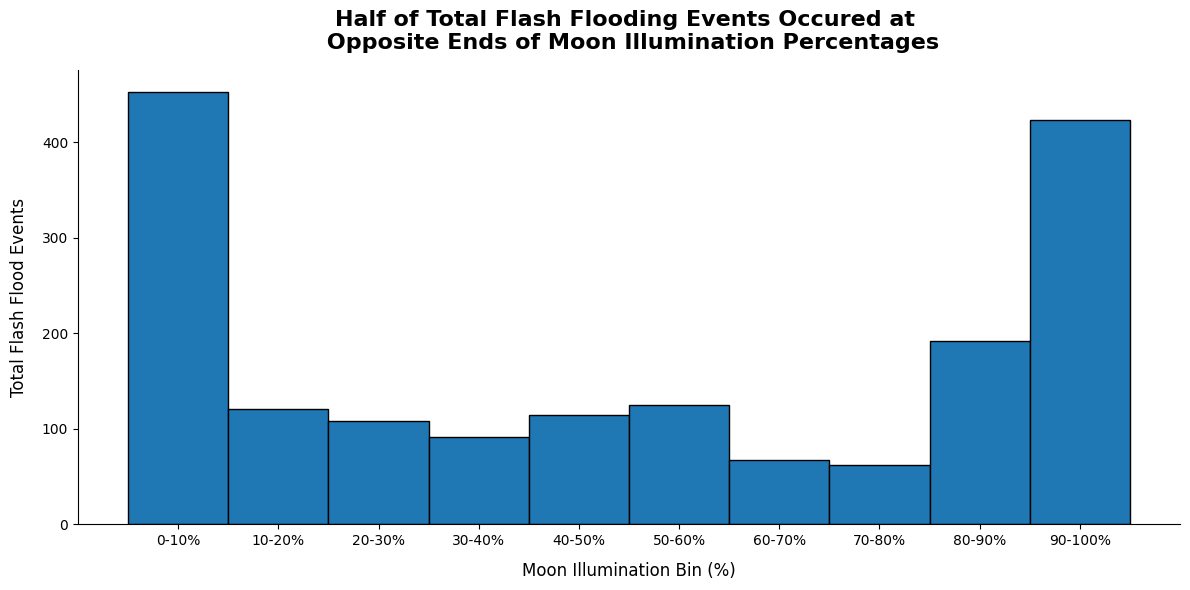

In [251]:
# Create a histogram to visualize the relationship between flash flooding events and moon illumination percentage by creating bins of 10% increments (0-10%, 10-20%, ..., 90-100%) and counting the number of events that occurred within each bin.
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.bar(
    result3["illumination_bin"], 
    result3["total_events"], 
    width=1.0, 
    edgecolor='black'
)

plt.title("Half of Total Flash Flooding Events Occured at \n Opposite Ends of Moon Illumination Percentages", 
    fontsize=16, 
    pad=15, 
    weight='bold'
)

plt.xlabel(
    "Moon Illumination Bin (%)", 
    fontsize=12, 
    labelpad=10
)

plt.ylabel(
    "Total Flash Flood Events", 
    fontsize=12, 
    labelpad=10
)

plt.grid(False)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [252]:
# Create a SQL query to compare the average number of flash flooding events per year during El Niño, La Niña, and Neutral ENSO phases.
query4 = """ SELECT 
o.enso_phase, 
    COUNT(e.event_id) AS total_events, 
    ROUND(CAST(COUNT(e.event_id) AS REAL) / COUNT(DISTINCT e.year), 2) AS avg_events_per_year
FROM event_info e
JOIN oni_data o ON e.event_id = o.event_id
GROUP BY o.enso_phase
ORDER BY avg_events_per_year DESC;
"""
result4 = pd.read_sql(query4, conn)
result4

,enso_phase,total_events,avg_events_per_year
0,Neutral,890,98.89
1,El Nino,466,66.57
2,La Nina,401,50.13


In [253]:
# Create a SQL query that groups flash flooding event dates, provides a count of events for each date, then lists the ENSO phase in which the event occurred.
query5 = """ SELECT 
i.begin_date AS "Date", 
    COUNT(i.event_id) AS "Flood_Count", 
    COALESCE(o.enso_phase, 'Neutral') AS "ENSO_Phase"
FROM event_info i
LEFT JOIN oni_data o ON i.event_id = o.event_id
WHERE i.begin_date >= '2015-01-01' AND i.begin_date <= '2025-12-31'
GROUP BY i.begin_date, o.enso_phase
ORDER BY "Flood_Count" DESC;
"""
result5 = pd.read_sql(query5, conn)
result5

,Date,Flood_Count,ENSO_Phase
0,2025-02-15,61,Neutral
1,2015-07-14,54,El Nino
2,2015-04-03,51,El Nino
3,2023-01-03,42,La Nina
4,2019-02-23,41,El Nino
...,...,...,...
348,2025-06-08,1,Neutral
349,2025-06-17,1,Neutral
350,2025-07-14,1,Neutral
351,2025-08-04,1,Neutral


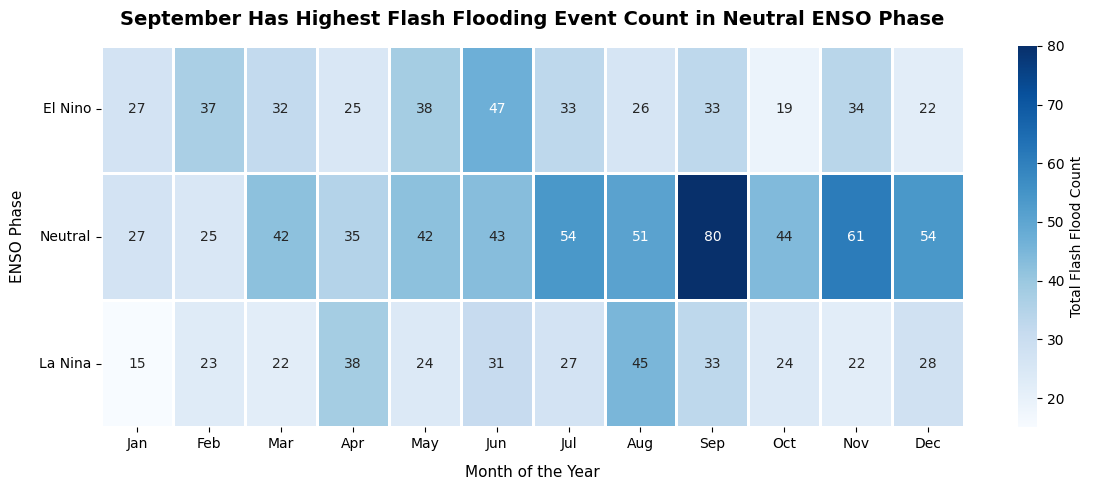

In [254]:
# Create a heatmap that shows the total number of flash flooding events by month and ENSO climate phases from 2015-2025.
date_range = pd.date_range(start="2015-01-01", end="2025-12-31", freq="MS")
np.random.seed(42)

flood_counts = np.random.randint(1, 20, size=len(date_range))
phases_cycle = (
    ["El Nino"] * 12 + ["Neutral"] * 12 + ["La Nina"] * 18 + ["Neutral"] * 12
)
enso_phases = [phases_cycle[i % len(phases_cycle)] for i in range(len(date_range))]

df = pd.DataFrame(
    {"Date": date_range, "Flood_Count": flood_counts, "ENSO_Phase": enso_phases}
)

df["Month_Num"] = df["Date"].dt.month

month_names = {
    1: "Jan",
    2: "Feb",
    3: "Mar",
    4: "Apr",
    5: "May",
    6: "Jun",
    7: "Jul",
    8: "Aug",
    9: "Sep",
    10: "Oct",
    11: "Nov",
    12: "Dec",
}
df["Month"] = df["Month_Num"].map(month_names)

heatmap_data = df.pivot_table(
    values="Flood_Count",
    index="ENSO_Phase",
    columns="Month_Num",
    aggfunc="sum",
    fill_value=0,
)

heatmap_data.columns = [month_names[m] for m in heatmap_data.columns]

desired_order = ["El Nino", "Neutral", "La Nina"]
heatmap_data = heatmap_data.reindex(desired_order)

plt.figure(figsize=(12, 5))

sns.heatmap(
    heatmap_data,
    annot=True,  
    fmt="d",  
    cmap="Blues",  
    linewidths=1,  
    cbar_kws={"label": "Total Flash Flood Count"}, 
)

plt.title(
    "September Has Highest Flash Flooding Event Count in Neutral ENSO Phase",
    fontsize=14,
    pad=15,
    fontweight="bold",
)

plt.xlabel(
    "Month of the Year", 
    fontsize=11, 
    labelpad=10
)

plt.ylabel(
    "ENSO Phase", 
    fontsize=11, 
    labelpad=10
)

plt.xticks(rotation=0)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

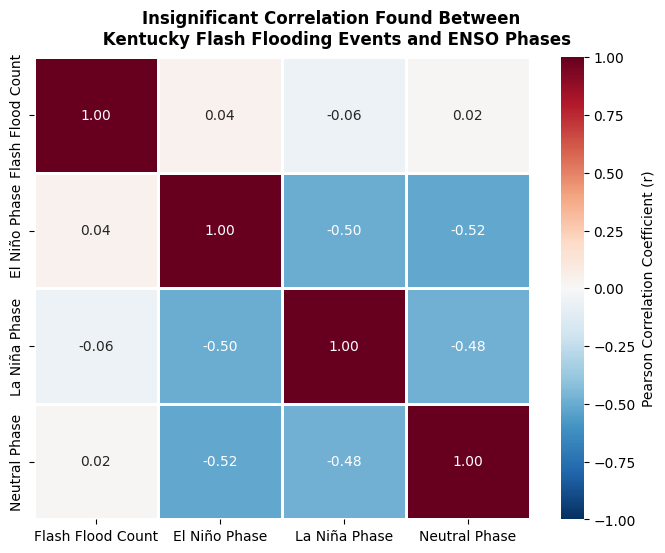

In [255]:
# Create a heatmap that shows correlation percentages between flash flooding events and ENSO climate phases from 2015-2025.
date_range = pd.date_range(start="2015-01-01", end="2025-12-31", freq="MS")
np.random.seed(42)
flood_counts = np.random.randint(1, 20, size=len(date_range))
phases_pool = ["El Nino", "La Nina", "Neutral"]
enso_phases = np.random.choice(phases_pool, size=len(date_range))

df = pd.DataFrame({"Flood_Count": flood_counts, "ENSO_Phase": enso_phases})
df_encoded = pd.get_dummies(df, columns=["ENSO_Phase"], dtype=int)
df_encoded = df_encoded.rename(
    columns={
        "ENSO_Phase_El Nino": "El Niño Phase",
        "ENSO_Phase_La Nina": "La Niña Phase",
        "ENSO_Phase_Neutral": "Neutral Phase",
        "Flood_Count": "Flash Flood Count",
    }
)

corr_matrix = df_encoded.corr(method="pearson")

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    linewidths=1,
    linecolor="white",
    cbar_kws={"label": "Pearson Correlation Coefficient (r)"},
)

plt.suptitle(
    "Insignificant Correlation Found Between \n Kentucky Flash Flooding Events and ENSO Phases",
    fontsize=12,
    fontweight="bold",
    y=0.96,
)

plt.show()

In [256]:
# Create a SQL query to analyze the relationship between flash flooding events, humidity, UV index, precipitation, and moon illumination percentages.
query6 = """ SELECT
    w.avghumidity, 
    w.uv, 
    w.totalprecip_in, 
    m.moon_illumination_pct
FROM weather_conditions w
INNER JOIN moon_sun_data m ON w.event_id = m.event_id
WHERE w.uv > 8;
"""
result6 = pd.read_sql(query6, conn)
result6

,avghumidity,uv,totalprecip_in,moon_illumination_pct
0,41,9.3,0.00,97.95
1,74,11.1,0.15,97.95
2,82,9.4,0.32,1.91
3,81,10.4,0.01,99.72
4,85,11.1,0.25,2.46
...,...,...,...,...
389,74,10.4,0.25,32.75
390,79,10.4,0.25,61.73
391,75,11.5,2.08,61.73
392,78,11.4,1.62,61.73


In [257]:
correlation_table = result6.corr(numeric_only=True) * 100

styled_table = (
    correlation_table.style
    .format("{:.2f}%") 
    .background_gradient(cmap="coolwarm", vmin=-100, vmax=100)  
    .set_caption("Weather and Moon Data Correlation Matrix (%)")
)

styled_table

,avghumidity,uv,totalprecip_in,moon_illumination_pct
avghumidity,100.00%,-28.20%,22.51%,-17.04%
uv,-28.20%,100.00%,-18.44%,5.32%
totalprecip_in,22.51%,-18.44%,100.00%,0.19%
moon_illumination_pct,-17.04%,5.32%,0.19%,100.00%


In [258]:
# Create a SQL query that counts the number of flash flooding events in each oni_season 
query7 = """ SELECT 
oni_season, COUNT(*) AS total_events
FROM oni_data
GROUP BY oni_season
ORDER BY total_events DESC;
""" 
result7 = pd.read_sql(query7, conn)
result7

,oni_season,total_events
0,JJA,456
1,AMJ,235
2,JFM,221
3,MJJ,213
4,JAS,164
5,MAM,150
6,ASO,114
7,DJF,81
8,FMA,65
9,SON,21


In [259]:
# Create a SQL subquery that analyzes average flash flood event duration between 2015 - 2025.
query8 = """ SELECT 
    sub.year,
    AVG(sub.duration_minutes) AS avg_duration
FROM (
    SELECT 
        e.duration_minutes, 
        e.year, 
        m.moon_illumination_pct 
    FROM event_info e 
    INNER JOIN moon_sun_data m ON e.event_id = m.event_id 
    WHERE e.duration_minutes > 60
) AS sub
GROUP BY sub.year;
"""
result8 = pd.read_sql(query8, conn)
result8

,year,avg_duration
0,2015,147.218182
1,2016,147.952941
2,2017,171.083333
3,2018,115.568966
4,2019,147.065421
5,2020,143.298969
6,2021,155.273224
7,2022,178.044776
8,2023,189.717172
9,2024,184.188679


In [260]:
# Create a common table expression (CTE) that examines the weather conditions during the most impactful flash flooding events.
query9 = """WITH 
HighImpact AS (
    SELECT 
        event_id,
        deaths_direct,
        SUM(damage_property_num) AS total_property_damage
    FROM 
        impact_data
    GROUP BY 
        event_id
    HAVING 
        SUM(deaths_direct) > 0
)
SELECT 
    w.event_id, 
    w.totalprecip_in,
    i.total_property_damage,
    i.deaths_direct,
    m.moon_illumination_pct    
FROM                           
    weather_conditions w       
INNER JOIN 
    HighImpact i ON w.event_id = i.event_id
INNER JOIN 
    moon_sun_data m ON w.event_id = m.event_id
ORDER BY 
    i.deaths_direct DESC;
"""
result9 = pd.read_sql(query9, conn)
result9

,event_id,totalprecip_in,total_property_damage,deaths_direct,moon_illumination_pct
0,1049192,0.48,0,16,2.90
1,1049130,1.57,0,10,2.90
2,1049154,0.62,0,6,0.68
3,584092,0.03,3500000,4,10.25
4,1049189,0.63,0,3,0.68
5,1049197,0.20,0,3,0.68
6,1236440,3.47,10000,2,94.36
7,566747,1.22,1000,1,97.95
8,587357,0.01,80000,1,85.13
9,588935,0.56,20000,1,98.77


In [261]:
query10 = """ SELECT
    w.uv,
    m.moon_illumination_pct
FROM weather_conditions w
INNER JOIN moon_sun_data m ON w.event_id = m.event_id
"""
result10 = pd.read_sql(query10, conn)
result10

,uv,moon_illumination_pct
0,2.7,97.95
1,2.7,97.95
2,1.3,97.95
3,1.9,97.95
4,2.7,97.95
...,...,...
1752,2.6,99.93
1753,2.7,99.93
1754,3.7,99.93
1755,3.1,99.93


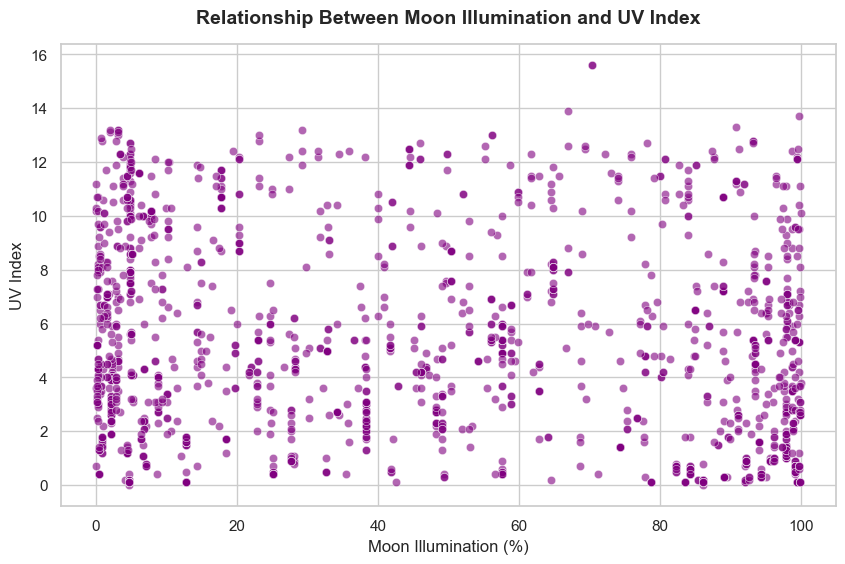

In [262]:
# Create a scatterplot that compares UV index to moon illumination percentages
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=result10, 
    x='moon_illumination_pct', 
    y='uv', 
    alpha=0.6,      
    color='purple'  
)

plt.title(
    'Relationship Between Moon Illumination and UV Index', 
    fontsize=14,
    fontweight='bold',
    pad=15
)

plt.xlabel(
    'Moon Illumination (%)', 
    fontsize=12
)

plt.ylabel(
    'UV Index', 
    fontsize=12
)

plt.show()

In [263]:
query11 = """ WITH 
annual_flood_damage AS (
    SELECT 
        CAST(strftime('%Y', begin_date) AS INTEGER) AS flood_year,
        SUM(damage_property_num) AS total_damage
    FROM impact_data
    INNER JOIN event_info 
    WHERE begin_date BETWEEN '2015-01-01' AND '2025-12-31'
    GROUP BY flood_year
)
SELECT 
    flood_year,
    total_damage,
    LAG(total_damage) OVER (ORDER BY flood_year) AS previous_year_damage,
    ROUND(
        CASE
            WHEN LAG(total_damage) OVER (ORDER BY flood_year) != 0
            THEN (
                (total_damage - LAG(total_damage) OVER (ORDER BY flood_year))
                / CAST(LAG(total_damage) OVER (ORDER BY flood_year) AS REAL)
            ) * 100.0
            ELSE NULL
        END,
        2
    ) AS yoy_percentage_change
FROM annual_flood_damage
ORDER BY flood_year;
"""
result11 = pd.read_sql(query11, conn)
result11

,flood_year,total_damage,previous_year_damage,yoy_percentage_change
0,2015,10104367020,NaN,NaN
1,2016,6650975760,1.010437e+10,-34.18
2,2017,5116135200,6.650976e+09,-23.08
3,2018,7205223740,5.116135e+09,40.83
4,2019,5670383180,7.205224e+09,-21.30
5,2020,7034685900,5.670383e+09,24.06
6,2021,9251677820,7.034686e+09,31.52
7,2022,6949416980,9.251678e+09,-24.88
8,2023,5158769660,6.949417e+09,-25.77
9,2024,2941777740,5.158770e+09,-42.98


In [264]:
conn.close()